In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
print("="*80)
print("TREASURY CASH FLOW EDA")
print("="*80)

TREASURY CASH FLOW EDA


##### ============================================================================
#### SECTION 1: DATA LOADING
##### ============================================================================


In [3]:
ACTUALS_FILE_PATH = 'Actuals_17C7.csv'
LP_FILE_PATH = 'LP_17C7.csv'
FX_RATES = 'eurofxref-hist.csv'

print("\n[1/10] Loading data...")
actuals_df = pd.read_csv(ACTUALS_FILE_PATH)
lp_df = pd.read_csv(LP_FILE_PATH)
fx_df = pd.read_csv(FX_RATES)

print(f"✓ Actuals: Loaded {len(actuals_df):,} rows")
print(f"✓ Actuals: Columns: {len(actuals_df.columns)}")

print(f"✓ LP: Loaded {len(lp_df):,} rows")
print(f"✓ LP: Columns: {len(lp_df.columns)}")

print(f"✓ FX: Loaded {len(fx_df):,} rows")
print(f"✓ FX: Columns: {len(fx_df.columns)}")



[1/10] Loading data...
✓ Actuals: Loaded 625,320 rows
✓ Actuals: Columns: 150
✓ LP: Loaded 31,666 rows
✓ LP: Columns: 50
✓ FX: Loaded 6,869 rows
✓ FX: Columns: 43


In [4]:
actuals_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 625320 entries, 0 to 625319
Columns: 150 entries, Account to Unnamed: 149
dtypes: float64(53), int64(17), object(80)
memory usage: 715.6+ MB


In [5]:
actuals_df.head(5)

,Account,IBAN,BIC,"Account for internal usage (Accruals, Taxes, etc)",Ledger Account Category,Status,Amount,Entity,Counterpart,PTP Account,...,Payment Record ID,End to End ID,VAID,Number of legs,Entity Group,Amount Functional Currency,Amount in Equivalence Currency,Amount Original Currency,PTP Amount,Unnamed: 149
0,4B9 CACIBFR EUR,FR7631489000100025731898147,BSUIFRPPXXX,No,Bank Account,Actual (Reconciled),-1297.12,4B9,CACIBFR,00,...,2.024000e+12,NaN,NaN,1,EUROPE POOL,-1297.12,-1297.12,-1297.12,-1297.12,NaN
1,4B9 CACIBFR EUR,FR7631489000100025731898147,BSUIFRPPXXX,No,Bank Account,Actual (Reconciled),-2008.60,4B9,CACIBFR,00,...,2.024000e+12,NaN,NaN,1,EUROPE POOL,-2008.60,-2008.60,-2008.60,-2008.60,NaN
2,4B9 CACIBFR EUR,FR7631489000100025731898147,BSUIFRPPXXX,No,Bank Account,Actual (Reconciled),-1990.00,4B9,CACIBFR,00,...,2.024000e+12,NaN,NaN,1,EUROPE POOL,-1990.00,-1990.00,-1990.00,-1990.00,NaN
3,4B9 KBCZ EUR,CZ7801000000350710550277,KOMBCZPPXXX,No,Bank Account,Actual (Reconciled),-2.94,4B9,KBCZ,00,...,NaN,NaN,NaN,1,EUROPE POOL,-2.94,-2.94,-2.94,-2.94,NaN
4,4B9 CACIBFR EUR,FR7631489000100025731898147,BSUIFRPPXXX,No,Bank Account,Actual (Reconciled),-1870.00,4B9,CACIBFR,00,...,2.024000e+12,NaN,NaN,1,EUROPE POOL,-1870.00,-1870.00,-1870.00,-1870.00,NaN


In [6]:
actual_entity_counts = actuals_df['Entity'].value_counts()
print(f"\nTotal Entities: {len(actual_entity_counts)}")
print("\nTransactions by Entity:")
print(actual_entity_counts)


Total Entities: 22

Transactions by Entity:
Entity
97R     107790
V798     86834
T056     84471
V756     78630
V002     59101
97C      53219
V751     28924
86W      28083
V265     20652
T055     18367
V508     14609
17C7      9289
4B9       6610
057       6593
14C1      6525
11G5      5972
20B2      4248
57        4096
82J       1042
97L        107
98Y         87
25A4        71
Name: count, dtype: int64


In [7]:
# Replace 57 with 057 as string 
actuals_df['Entity'] = actuals_df['Entity'].astype(str).replace('57', '057')


In [8]:
actual_entity_counts = actuals_df['Entity'].value_counts()
print(f"\nTotal Entities: {len(actual_entity_counts)}")
print("\nTransactions by Entity:")
print(actual_entity_counts)


Total Entities: 21

Transactions by Entity:
Entity
97R     107790
V798     86834
T056     84471
V756     78630
V002     59101
97C      53219
V751     28924
86W      28083
V265     20652
T055     18367
V508     14609
057      10689
17C7      9289
4B9       6610
14C1      6525
11G5      5972
20B2      4248
82J       1042
97L        107
98Y         87
25A4        71
Name: count, dtype: int64


In [9]:
lp_entity_counts = lp_df['Entity'].value_counts()
print(f"\nTotal Entities: {len(lp_entity_counts)}")
print("\nLP Transactions by Entity:")
print(lp_entity_counts)


Total Entities: 21

LP Transactions by Entity:
Entity
17C7    2810
4B9     2324
97R     2133
97L     1899
V508    1898
98Y     1890
V751    1728
V756    1706
97C     1668
V798    1667
V265    1591
57      1570
T056    1530
T055    1463
82J     1370
86W     1248
V002    1117
11G5     798
14C1     795
25A4     450
20B2      11
Name: count, dtype: int64


In [10]:
# Replace 57 with 057 as string 
lp_df['Entity'] = lp_df['Entity'].astype(str).replace('57', '057')


In [11]:
lp_entity_counts = lp_df['Entity'].value_counts()
print(f"\nTotal Entities: {len(lp_entity_counts)}")
print("\nLP Transactions by Entity:")
print(lp_entity_counts)


Total Entities: 21

LP Transactions by Entity:
Entity
17C7    2810
4B9     2324
97R     2133
97L     1899
V508    1898
98Y     1890
V751    1728
V756    1706
97C     1668
V798    1667
V265    1591
057     1570
T056    1530
T055    1463
82J     1370
86W     1248
V002    1117
11G5     798
14C1     795
25A4     450
20B2      11
Name: count, dtype: int64


In [12]:
lp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31666 entries, 0 to 31665
Data columns (total 50 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   PLAN-ID                                31666 non-null  int64  
 1   Item-ID                                31666 non-null  object 
 2   Entity                                 31666 non-null  object 
 3   Group Description                      31666 non-null  object 
 4   Liquidity Group/Super Liquidity Group  31666 non-null  object 
 5   Item's Date                            31666 non-null  object 
 6   Amount                                 31666 non-null  float64
 7   Currency                               31666 non-null  object 
 8   Credit/Debit                           31666 non-null  object 
 9   Origin                                 31666 non-null  object 
 10  Item Status                            31666 non-null  object 
 11  Pl

In [13]:
lp_df.tail(5)

,PLAN-ID,Item-ID,Entity,Group Description,Liquidity Group/Super Liquidity Group,Item's Date,Amount,Currency,Credit/Debit,Origin,...,Consolidation possible,Exposure Aggregation,Entity ID,Entity Name,Entity Short Name,Group ID,Type,Project ID,Super Liquidity Group,Original Liquidity Group
31661,27703,LX2544000398686,V798,Trade Payables incl. VAT,TRP,11/10/2025,-724173.0,EUR,Debit,LP,...,No,No,ITS000015605411,ASSS GERMANY,V798,ITS000015609332,Liquidity Group,NaN,No,NaN
31662,27703,LX2544000398687,V798,Trade Payables incl. VAT,TRP,11/17/2025,-725306.0,EUR,Debit,LP,...,No,No,ITS000015605411,ASSS GERMANY,V798,ITS000015609332,Liquidity Group,NaN,No,NaN
31663,27703,LX2544000398688,V798,HR Payments,HRP,10/27/2025,-1453500.0,EUR,Debit,LP,...,No,No,ITS000015605411,ASSS GERMANY,V798,ITS000015609341,Liquidity Group,NaN,No,NaN
31664,27703,LX2544000398689,V798,HR Payments,HRP,11/10/2025,-233500.0,EUR,Debit,LP,...,No,No,ITS000015605411,ASSS GERMANY,V798,ITS000015609341,Liquidity Group,NaN,No,NaN
31665,27703,LX2544000398690,V798,Other payables,OTP,11/10/2025,-8500000.0,EUR,Debit,LP,...,No,No,ITS000015605411,ASSS GERMANY,V798,ITS000015609345,Liquidity Group,NaN,No,NaN


#### =============================================================================
#### SECTION 2: FILTER ACTUALS (150 cols → 5 cols, only TRR+TRP) and FILTER LP (50 cols -> 11 cols, only TRR+TRP)
#### =============================================================================


In [14]:
print("[2/10] Filtering actuals...")

actuals_filtered = actuals_df[[
    'Entity',
    'Value Date',
    'Amount Functional Currency',
    'Liquidity Group'
]].copy()

# Keep only TRR and TRP
actuals_filtered = actuals_filtered[
    actuals_filtered['Liquidity Group'].isin(['TRR', 'TRP'])
].copy()

print(f" ACTUALS: Original: {len(actuals_df):,} rows → Filtered: {len(actuals_filtered):,} rows")
actuals_filtered.to_csv('actuals_curated.csv', index=False)

lp_filtered = lp_df[[
    "Entity",
    "Entity Name",
    "Liquidity Group/Super Liquidity Group",
    "Year Title",
    "Item's Date",
    "Amount",
    "Currency",
    "Plan Currency",
    "Amount in plan currency",
    "Rate",
    "Comment"
]].copy()

# Keep only TRR and TRP
lp_filtered = lp_filtered[
    lp_filtered['Liquidity Group/Super Liquidity Group'].isin(['TRR', 'TRP'])
].copy()

print(f" LP: Original: {len(lp_df):,} rows → Filtered: {len(lp_filtered):,} rows")
lp_filtered.to_csv('lp_curated.csv', index=False)


[2/10] Filtering actuals...
 ACTUALS: Original: 625,320 rows → Filtered: 578,972 rows
 LP: Original: 31,666 rows → Filtered: 24,810 rows


In [15]:
actuals_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 578972 entries, 0 to 625319
Data columns (total 4 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Entity                      578972 non-null  object 
 1   Value Date                  578972 non-null  object 
 2   Amount Functional Currency  578972 non-null  float64
 3   Liquidity Group             578972 non-null  object 
dtypes: float64(1), object(3)
memory usage: 22.1+ MB


#### =============================================================================
#### SECTION 3: Prepare FX Lookup
#### =============================================================================

In [16]:
print("\n[3/10] Prepare FX rates lookup...")

fx_df['Date'] = pd.to_datetime(fx_df['Date'])
fx_lookup = fx_df.set_index('Date')[['USD', 'CHF']].to_dict('index')



[3/10] Prepare FX rates lookup...


#### =============================================================================
#### SECTION 4: Convert non-EUR Plan currency to EUR 
#### =============================================================================

In [17]:
print("\n[4/10] Converting non-EUR Plan Currency to EUR...")

def convert_to_eur(row):
    """Convert USD/CHF to EUR using FX rates"""
    if row['Plan Currency'] == 'EUR':
        return row['Amount in plan currency']  # Already in EUR
    
    # Need conversion
    item_date = pd.to_datetime(row["Item's Date"])
    currency = row['Plan Currency']
    
    # Find closest FX rate (handle weekends/missing dates)
    while item_date not in fx_lookup and item_date >= fx_df['Date'].min():
        item_date -= pd.Timedelta(days=1)
    
    if item_date in fx_lookup:
        #print("\n FX conversion...")
        rate = fx_lookup[item_date].get(currency)
        if rate and not pd.isna(rate):
            return row['Amount'] / float(rate)  # Convert to EUR
    
    # Fallback: use Amount in plan currency as-is
    return row['Amount in plan currency']



[4/10] Converting non-EUR Plan Currency to EUR...


In [18]:
lp_filtered['Amount_EUR'] = lp_filtered.apply(convert_to_eur, axis=1)

In [19]:
lp_filtered.tail(10)

,Entity,Entity Name,Liquidity Group/Super Liquidity Group,Year Title,Item's Date,Amount,Currency,Plan Currency,Amount in plan currency,Rate,Comment,Amount_EUR
31651,V756,ASSS ITALY,TRP,2025/CW44,11/10/2025,-80657.0,EUR,EUR,-80657.0,1.0,NaN,-80657.0
31652,V756,ASSS ITALY,TRP,2025/CW44,11/17/2025,-26994.0,EUR,EUR,-26994.0,1.0,NaN,-26994.0
31655,V798,ASSS GERMANY,TRR,2025/CW44,10/27/2025,15000000.0,EUR,EUR,15000000.0,1.0,NaN,15000000.0
31656,V798,ASSS GERMANY,TRR,2025/CW44,11/03/2025,13000000.0,EUR,EUR,13000000.0,1.0,NaN,13000000.0
31657,V798,ASSS GERMANY,TRR,2025/CW44,11/10/2025,7500000.0,EUR,EUR,7500000.0,1.0,NaN,7500000.0
31658,V798,ASSS GERMANY,TRR,2025/CW44,11/17/2025,3000000.0,EUR,EUR,3000000.0,1.0,NaN,3000000.0
31659,V798,ASSS GERMANY,TRP,2025/CW44,10/27/2025,-1025335.0,EUR,EUR,-1025335.0,1.0,NaN,-1025335.0
31660,V798,ASSS GERMANY,TRP,2025/CW44,11/03/2025,-753831.0,EUR,EUR,-753831.0,1.0,NaN,-753831.0
31661,V798,ASSS GERMANY,TRP,2025/CW44,11/10/2025,-724173.0,EUR,EUR,-724173.0,1.0,NaN,-724173.0
31662,V798,ASSS GERMANY,TRP,2025/CW44,11/17/2025,-725306.0,EUR,EUR,-725306.0,1.0,NaN,-725306.0


In [20]:
print("\n[4.1/10] Checking for weekend data entries...")

lp_filtered["Item's Date"] = pd.to_datetime(lp_filtered["Item's Date"], errors='coerce')
lp_filtered['DayOfWeek'] = lp_filtered["Item's Date"].dt.day_name()
weekend_data = lp_filtered[lp_filtered['DayOfWeek'].isin(['Saturday', 'Sunday'])].copy()

if len(weekend_data) > 0:
    print(f"  ⚠️  WARNING: Found {len(weekend_data):,} weekend entries ({len(weekend_data)/len(lp_filtered)*100:.2f}%)")
    print("\n  Weekend Entry Breakdown:")
    print(weekend_data.groupby(['Year Title', 'Entity', 'DayOfWeek']).size().head(20))
    
    # Save detailed weekend anomalies
    weekend_summary = weekend_data.groupby(['Year Title', 'Entity', 'Liquidity Group/Super Liquidity Group', 'DayOfWeek']).agg({
        "Item's Date": 'count',
        'Amount in plan currency': 'sum'
    }).reset_index()
    weekend_summary.columns = ['Year_Title', 'Entity', 'Liquidity Group/Super Liquidity Group', 'Day_Of_Week', 'Count', 'Total_Amount']
    weekend_summary.to_csv('LP_ANOMALY_1_Weekend_Entries.csv', index=False)
    print(f"  ✓ Saved: LP_ANOMALY_1_Weekend_Entries.csv")
else:
    print("  ✓ No weekend entries found")


[4.1/10] Checking for weekend data entries...
  ✓ No weekend entries found


In [21]:
print("\n[4.2/10] Analyzing entity data coverage...")

entity_coverage = lp_filtered.groupby('Entity').agg({
    "Item's Date": ['min', 'max', 'count'],
    'Year Title': 'nunique'
}).reset_index()
entity_coverage.columns = ['Entity', 'First_Date', 'Last_Date', 'Total_Rows', 'Unique_Weeks']

# Calculate data span
entity_coverage['Data_Span_Days'] = (entity_coverage['Last_Date'] - entity_coverage['First_Date']).dt.days
entity_coverage['Data_Span_Years'] = entity_coverage['Data_Span_Days'] / 365.25

# Flag entities with limited data
entity_coverage['Has_Limited_Data'] = entity_coverage['Data_Span_Years'] < 2.0

print("\n  Entity Coverage Summary:")
print(entity_coverage.sort_values('Data_Span_Years').to_string(index=False))

# Entities with < 2 years of data
limited_entities = entity_coverage[entity_coverage['Has_Limited_Data']]
if len(limited_entities) > 0:
    print(f"\n  ⚠️  WARNING: {len(limited_entities)} entities have < 2 years of data:")
    print(limited_entities[['Entity', 'First_Date', 'Data_Span_Years']].to_string(index=False))

entity_coverage.to_csv('LP_ANOMALY_2_Entity_Coverage.csv', index=False)
print(f"\n  ✓ Saved: LP_ANOMALY_3_Entity_Coverage.csv")



[4.2/10] Analyzing entity data coverage...

  Entity Coverage Summary:
Entity First_Date  Last_Date  Total_Rows  Unique_Weeks  Data_Span_Days  Data_Span_Years  Has_Limited_Data
  25A4 2025-03-10 2025-11-17         232            29             252         0.689938              True
  20B2 2024-07-01 2025-05-12          11             5             315         0.862423              True
   4B9 2022-01-03 2025-11-10        1417           197            1407         3.852156             False
   057 2022-01-03 2025-11-17        1570           202            1414         3.871321             False
  17C7 2022-01-03 2025-11-17         801           202            1414         3.871321             False
  14C1 2022-01-03 2025-11-17         794           202            1414         3.871321             False
  11G5 2022-01-03 2025-11-17         796           202            1414         3.871321             False
   82J 2022-01-03 2025-11-17        1082           147            1414         3

In [22]:
print("\n[4.3/10] Analyzing forecast counts per Year+Entity+LiquidityGroup...")

# Count number of forecasts per combination
forecast_counts = lp_filtered.groupby(['Year Title', 'Entity', 'Liquidity Group/Super Liquidity Group']).agg({
    "Item's Date": 'count'
}).reset_index()
forecast_counts.columns = ['Year_Title', 'Entity', 'Liquidity Group/Super Liquidity Group', 'Forecast_Count']

# Identify anomalies (not equal to 4)
anomalies = forecast_counts[forecast_counts['Forecast_Count'] != 4].copy()

print(f"\n  Total unique combinations: {len(forecast_counts):,}")
print(f"  Expected forecast count: 4 per combination")
print(f"  Combinations with exactly 4 forecasts: {len(forecast_counts[forecast_counts['Forecast_Count'] == 4]):,} ({len(forecast_counts[forecast_counts['Forecast_Count'] == 4])/len(forecast_counts)*100:.1f}%)")
print(f"  ⚠️  ANOMALIES (≠ 4 forecasts): {len(anomalies):,} ({len(anomalies)/len(forecast_counts)*100:.1f}%)")

# Breakdown by forecast count
print("\n  Forecast Count Distribution:")
count_dist = forecast_counts['Forecast_Count'].value_counts().sort_index()
for count, freq in count_dist.items():
    print(f"    {count} forecasts: {freq:,} combinations ({freq/len(forecast_counts)*100:.1f}%)")


[4.3/10] Analyzing forecast counts per Year+Entity+LiquidityGroup...

  Total unique combinations: 6,590
  Expected forecast count: 4 per combination
  Combinations with exactly 4 forecasts: 5,593 (84.9%)
  ⚠️  ANOMALIES (≠ 4 forecasts): 997 (15.1%)

  Forecast Count Distribution:
    1 forecasts: 172 combinations (2.6%)
    2 forecasts: 230 combinations (3.5%)
    3 forecasts: 588 combinations (8.9%)
    4 forecasts: 5,593 combinations (84.9%)
    5 forecasts: 4 combinations (0.1%)
    6 forecasts: 1 combinations (0.0%)
    8 forecasts: 2 combinations (0.0%)


In [23]:
print("\n[4.4/10] Creating detailed anomaly reports...")

if len(anomalies) > 0:
    # Sort by forecast count to see patterns
    anomalies_sorted = anomalies.sort_values(['Forecast_Count', 'Entity', 'Year_Title'])
    
    print(f"\n  Top 20 anomalies (lowest forecast counts):")
    print(anomalies_sorted.head(20).to_string(index=False))
    
    # Analyze patterns
    print("\n  Anomaly Patterns:")
    print("\n    By Entity:")
    entity_anomalies = anomalies.groupby('Entity')['Forecast_Count'].agg(['count', 'mean', 'min', 'max'])
    entity_anomalies.columns = ['Anomaly_Count', 'Avg_Forecast_Count', 'Min_Forecast_Count', 'Max_Forecast_Count']
    print(entity_anomalies.sort_values('Anomaly_Count', ascending=False).to_string())
    
    print("\n    By Liquidity Group:")
    liq_anomalies = anomalies.groupby('Liquidity Group/Super Liquidity Group')['Forecast_Count'].agg(['count', 'mean', 'min', 'max'])
    liq_anomalies.columns = ['Anomaly_Count', 'Avg_Forecast_Count', 'Min_Forecast_Count', 'Max_Forecast_Count']
    print(liq_anomalies.to_string())
    
    print("\n    By Year (calendar week year):")
    anomalies['Year'] = anomalies['Year_Title'].str.split('/').str[0]
    year_anomalies = anomalies.groupby('Year')['Forecast_Count'].agg(['count', 'mean'])
    year_anomalies.columns = ['Anomaly_Count', 'Avg_Forecast_Count']
    print(year_anomalies.sort_values('Anomaly_Count', ascending=False).to_string())
    
    # Get detailed records for anomalies
    print("\n  Fetching detailed records for anomalies...")
    
    # Merge back to get actual dates and amounts
    anomaly_details = anomalies.merge(
        lp_filtered,
        left_on=['Year_Title', 'Entity', 'Liquidity Group/Super Liquidity Group'],
        right_on=['Year Title', 'Entity', 'Liquidity Group/Super Liquidity Group'],
        how='left'
    )
    
    anomaly_details = anomaly_details[[
        'Year_Title', 'Entity', 'Liquidity Group/Super Liquidity Group', 'Forecast_Count',
        "Item's Date", 'Amount in plan currency', 'Plan Currency'
    ]].sort_values(['Forecast_Count', 'Entity', 'Year_Title', "Item's Date"])
    
    # Save all anomalies
    anomalies_sorted.to_csv('LP_ANOMALY_4A_Forecast_Count_Summary.csv', index=False)
    print(f"  ✓ Saved: LP_ANOMALY_4A_Forecast_Count_Summary.csv ({len(anomalies):,} rows)")
    
    anomaly_details.to_csv('LP_ANOMALY_4B_Forecast_Count_Details.csv', index=False)
    print(f"  ✓ Saved: LP_ANOMALY_4B_Forecast_Count_Details.csv ({len(anomaly_details):,} rows)")
    
    # Create a summary for treasury team
    print("\n  Creating summary for treasury team...")
    
    # Cases with < 4 forecasts (missing data)
    missing_forecasts = anomalies[anomalies['Forecast_Count'] < 4].copy()
    if len(missing_forecasts) > 0:
        print(f"\n    ⚠️  {len(missing_forecasts):,} combinations with MISSING forecasts (< 4):")
        print(f"       Most common entities: {missing_forecasts['Entity'].value_counts().head(5).to_dict()}")
        missing_forecasts.to_csv('LP_ANOMALY_4C_Missing_Forecasts.csv', index=False)
        print(f"       ✓ Saved: LP_ANOMALY_4C_Missing_Forecasts.csv")
    
    # Cases with > 4 forecasts (duplicate/extra data)
    extra_forecasts = anomalies[anomalies['Forecast_Count'] > 4].copy()
    if len(extra_forecasts) > 0:
        print(f"\n    ⚠️  {len(extra_forecasts):,} combinations with EXTRA forecasts (> 4):")
        print(f"       Most common entities: {extra_forecasts['Entity'].value_counts().head(5).to_dict()}")
        extra_forecasts.to_csv('LP_ANOMALY_4D_Extra_Forecasts.csv', index=False)
        print(f"       ✓ Saved: LP_ANOMALY_4D_Extra_Forecasts.csv")
    
else:
    print("  ✓ No forecast count anomalies found (all combinations have exactly 4 forecasts)")


[4.4/10] Creating detailed anomaly reports...

  Top 20 anomalies (lowest forecast counts):
Year_Title Entity Liquidity Group/Super Liquidity Group  Forecast_Count
 2021/CW50    057                                   TRR               1
 2021/CW51    057                                   TRP               1
 2021/CW50   11G5                                   TRP               1
 2022/CW05   11G5                                   TRR               1
 2022/CW06   11G5                                   TRR               1
 2022/CW19   11G5                                   TRR               1
 2021/CW50   14C1                                   TRP               1
 2022/CW38   14C1                                   TRR               1
 2024/CW52   14C1                                   TRR               1
 2021/CW50   17C7                                   TRP               1
 2023/CW19   17C7                                   TRP               1
 2024/CW27   20B2                          

In [24]:
print("\n[4.5/10] Creating LP Summary anomaly reports...")
print("\n" + "="*100)
print("SUMMARY - DATA QUALITY ISSUES TO DISCUSS WITH TREASURY")
print("="*100)

print("\n1. WEEKEND DATA ENTRIES:")
if len(weekend_data) > 0:
    print(f"   ⚠️  Found {len(weekend_data):,} weekend entries")
    print(f"   Question for treasury: Why are forecasts being made on weekends?")
else:
    print("   ✓ No issues")

print("\n2. ENTITY DATA COVERAGE:")
unique_entities = lp_filtered['Entity'].nunique()
print(f"   ⚠️  Only {unique_entities} entities have TRR/TRP data (after filtering)")
if len(limited_entities) > 0:
    print(f"   ⚠️  {len(limited_entities)} entities have < 2 years of data:")
    for _, row in limited_entities.iterrows():
        print(f"       - Entity {row['Entity']}: Only {row['Data_Span_Years']:.1f} years (from {row['First_Date'].strftime('%Y-%m-%d')})")
    print(f"   Question for treasury: Are these new entities? Should we exclude them from modeling?")

print("\n3. FORECAST COUNT ANOMALIES:")
if len(anomalies) > 0:
    print(f"   ⚠️  {len(anomalies):,} combinations don't have exactly 4 forecasts ({len(anomalies)/len(forecast_counts)*100:.1f}% of data)")
    if len(missing_forecasts) > 0:
        print(f"       - {len(missing_forecasts):,} combinations with < 4 forecasts (missing data)")
        print(f"         Most affected entities: {', '.join(map(str, missing_forecasts['Entity'].value_counts().head(3).index))}")
    if len(extra_forecasts) > 0:
        print(f"       - {len(extra_forecasts):,} combinations with > 4 forecasts (duplicate/extra data)")
        print(f"         Most affected entities: {', '.join(map(str, extra_forecasts['Entity'].value_counts().head(3).index))}")
    print(f"\n   CRITICAL QUESTIONS FOR TREASURY:")
    print(f"   Q1: Why do some weeks have < 4 forecasts? Were forecasts not made for all 4 weeks?")
    print(f"   Q2: Why do some weeks have > 4 forecasts? Are there duplicate entries or revised forecasts?")
    print(f"   Q3: How should we handle these in modeling? Take first 4? Take last 4? Average?")
else:
    print("   ✓ All combinations have exactly 4 forecasts")

print("\n4. MISSING/NaN VALUES (check for longer horizons W3, W4):")
print("   Note: This requires checking the pivoted wide format for NaN values")
print("   Recommendation: Run separate analysis on lp_wide dataframe after transformation")

print("\n" + "="*100)
print("FILES GENERATED:")
print("="*100)
print("  1. LP_ANOMALY_1_Weekend_Entries.csv - Weekend forecast entries")
print("  2. LP_ANOMALY_3_Entity_Coverage.csv - Entity data coverage analysis")
print("  3. LP_ANOMALY_4A_Forecast_Count_Summary.csv - Summary of forecast count anomalies")
print("  4. LP_ANOMALY_4B_Forecast_Count_Details.csv - Detailed records for all anomalies")
print("  5. LP_ANOMALY_4C_Missing_Forecasts.csv - Combinations with < 4 forecasts")
print("  6. LP_ANOMALY_4D_Extra_Forecasts.csv - Combinations with > 4 forecasts")
print("\n✓ Share these files with treasury team for investigation!")
print("="*100)


[4.5/10] Creating LP Summary anomaly reports...

SUMMARY - DATA QUALITY ISSUES TO DISCUSS WITH TREASURY

1. WEEKEND DATA ENTRIES:
   ✓ No issues

2. ENTITY DATA COVERAGE:
   ⚠️  Only 21 entities have TRR/TRP data (after filtering)
   ⚠️  2 entities have < 2 years of data:
       - Entity 20B2: Only 0.9 years (from 2024-07-01)
       - Entity 25A4: Only 0.7 years (from 2025-03-10)
   Question for treasury: Are these new entities? Should we exclude them from modeling?

3. FORECAST COUNT ANOMALIES:
   ⚠️  997 combinations don't have exactly 4 forecasts (15.1% of data)
       - 990 combinations with < 4 forecasts (missing data)
         Most affected entities: 86W, V508, T055
       - 7 combinations with > 4 forecasts (duplicate/extra data)
         Most affected entities: 17C7, V798, 25A4

   CRITICAL QUESTIONS FOR TREASURY:
   Q1: Why do some weeks have < 4 forecasts? Were forecasts not made for all 4 weeks?
   Q2: Why do some weeks have > 4 forecasts? Are there duplicate entries or rev

#### =============================================================================
#### SECTION 5: PIVOT LP TO WIDE FORMAT
#### =============================================================================

In [25]:
lp_filtered.rename(columns={'Liquidity Group/Super Liquidity Group': 'Liquidity_Group'}, inplace=True)

In [26]:
print("\n[5/10] Pivoting LP to wide format...")

# Sort by date within each group
lp_filtered['Item_Date'] = pd.to_datetime(lp_filtered["Item's Date"])
lp_filtered = lp_filtered.sort_values(['Entity', 'Entity Name', 'Year Title', 'Liquidity_Group', 'Item_Date'])

# Create week number (1, 2, 3, 4) within each Entity+YearTitle+LiqGroup
lp_filtered['Week_Num'] = lp_filtered.groupby(
    ['Entity', 'Entity Name', 'Year Title', 'Liquidity_Group']
).cumcount() + 1

# Keep only first 4 weeks
lp_filtered = lp_filtered[lp_filtered['Week_Num'] <= 4]

# Pivot
lp_wide = lp_filtered.pivot_table(
    index=['Entity', 'Entity Name', 'Year Title', 'Liquidity_Group'],
    columns='Week_Num',
    values='Amount_EUR',
    aggfunc='first'  # Take first value if duplicates
).reset_index()

# Rename columns
lp_wide.columns = ['Entity', 'Entity Name', 'Year_Title', 'Liquidity_Group', 
                    'W1_Forecast', 'W2_Forecast', 'W3_Forecast', 'W4_Forecast']

print(f"  LP pivoted: {len(lp_wide)} forecast combinations")
print("\nSample:")
print(lp_wide.head())

# Save
lp_wide.to_csv('lp_curated_pivoted.csv', index=False)

print("\n✅ DONE!")
print("  - actuals_curated.csv (filtered actuals)")
print("  - lp_curated.csv (pivoted LP with EUR conversion)")


[5/10] Pivoting LP to wide format...
  LP pivoted: 6590 forecast combinations

Sample:
  Entity      Entity Name Year_Title Liquidity_Group  W1_Forecast  \
0    057  ASSS LUXEMBOURG  2021/CW50             TRR     388588.0   
1    057  ASSS LUXEMBOURG  2021/CW51             TRP     -23110.0   
2    057  ASSS LUXEMBOURG  2021/CW51             TRR     689496.0   
3    057  ASSS LUXEMBOURG  2021/CW52             TRP      -6334.0   
4    057  ASSS LUXEMBOURG  2021/CW52             TRR     659318.0   

   W2_Forecast  W3_Forecast  W4_Forecast  
0          NaN          NaN          NaN  
1          NaN          NaN          NaN  
2    1169374.0          NaN          NaN  
3     -30095.0     -24393.0          NaN  
4    1070308.0     726336.0          NaN  

✅ DONE!
  - actuals_curated.csv (filtered actuals)
  - lp_curated.csv (pivoted LP with EUR conversion)


In [27]:
actuals_filtered.shape

(578972, 4)

In [28]:
lp_wide.shape

(6590, 8)

In [29]:
actuals_filtered.describe()

,Amount Functional Currency
count,5.789720e+05
mean,1.032825e+04
std,4.437472e+05
min,-3.953450e+07
25%,-2.456165e+03
50%,6.834500e+01
75%,1.786845e+04
max,4.530800e+07


In [30]:
lp_wide.describe()

,W1_Forecast,W2_Forecast,W3_Forecast,W4_Forecast
count,6.590000e+03,6.418000e+03,6.188000e+03,5.600000e+03
mean,2.508777e+05,3.546934e+05,-5.892446e+05,-5.030330e+04
std,1.123718e+07,9.986371e+06,4.784639e+07,9.515535e+06
min,-1.354689e+08,-1.256533e+08,-3.691311e+09,-1.251842e+08
25%,-5.341858e+05,-4.639022e+05,-4.375105e+05,-4.302040e+05
50%,-2.655891e+04,-1.969200e+04,-1.876950e+04,-1.698050e+04
75%,1.858645e+06,1.500000e+06,1.358779e+06,1.543576e+06
max,9.284382e+07,8.094854e+07,9.284382e+07,7.104391e+07


In [31]:
print("\n[5.1/10] Analyzing forecast availability...")

# Check which forecast weeks have NaN/missing values
forecast_cols = ['W1_Forecast', 'W2_Forecast', 'W3_Forecast', 'W4_Forecast']

print("\n  Missing Forecast Distribution:")
for col in forecast_cols:
    missing = lp_wide[col].isna().sum()
    missing_pct = (missing / len(lp_wide)) * 100
    present = len(lp_wide) - missing
    print(f"    {col}:")
    print(f"      Present: {present:,} ({100-missing_pct:.2f}%)")
    print(f"      Missing: {missing:,} ({missing_pct:.2f}%)")

# Create a flag for each forecast week availability
for col in forecast_cols:
    lp_wide[f'{col}_Available'] = ~lp_wide[col].isna()

# Count how many forecasts are available per row
lp_wide['Available_Forecast_Count'] = (
    lp_wide['W1_Forecast_Available'].astype(int) +
    lp_wide['W2_Forecast_Available'].astype(int) +
    lp_wide['W3_Forecast_Available'].astype(int) +
    lp_wide['W4_Forecast_Available'].astype(int)
)

print("\n  Forecast Availability Distribution:")
avail_dist = lp_wide['Available_Forecast_Count'].value_counts().sort_index()
for count, freq in avail_dist.items():
    print(f"    {count} forecasts available: {freq:,} rows ({freq/len(lp_wide)*100:.1f}%)")


[5.1/10] Analyzing forecast availability...

  Missing Forecast Distribution:
    W1_Forecast:
      Present: 6,590 (100.00%)
      Missing: 0 (0.00%)
    W2_Forecast:
      Present: 6,418 (97.39%)
      Missing: 172 (2.61%)
    W3_Forecast:
      Present: 6,188 (93.90%)
      Missing: 402 (6.10%)
    W4_Forecast:
      Present: 5,600 (84.98%)
      Missing: 990 (15.02%)

  Forecast Availability Distribution:
    1 forecasts available: 172 rows (2.6%)
    2 forecasts available: 230 rows (3.5%)
    3 forecasts available: 588 rows (8.9%)
    4 forecasts available: 5,600 rows (85.0%)


In [32]:
print("\n[5.2/10] Identifying anomalies (rows with ≠ 4 forecasts)...")

# Rows with exactly 4 forecasts (GOOD)
complete_rows = lp_wide[lp_wide['Available_Forecast_Count'] == 4].copy()
print(f"\n  ✓ Complete rows (4 forecasts): {len(complete_rows):,} ({len(complete_rows)/len(lp_wide)*100:.1f}%)")

# Rows with < 4 forecasts (MISSING DATA)
incomplete_rows = lp_wide[lp_wide['Available_Forecast_Count'] < 4].copy()
if len(incomplete_rows) > 0:
    print(f"\n  ⚠️  ANOMALY: {len(incomplete_rows):,} rows with MISSING forecasts ({len(incomplete_rows)/len(lp_wide)*100:.1f}%)")
    
    # Pattern analysis
    print("\n    Breakdown by Entity:")
    entity_missing = incomplete_rows.groupby('Entity').agg({
        'Available_Forecast_Count': ['count', 'mean']
    }).round(2)
    entity_missing.columns = ['Anomaly_Count', 'Avg_Available_Forecasts']
    print(entity_missing.sort_values('Anomaly_Count', ascending=False).to_string())
    
    print("\n    Breakdown by Liquidity Group:")
    liq_missing = incomplete_rows.groupby('Liquidity_Group').agg({
        'Available_Forecast_Count': ['count', 'mean']
    }).round(2)
    liq_missing.columns = ['Anomaly_Count', 'Avg_Available_Forecasts']
    print(liq_missing.to_string())
    
    print("\n    Which forecasts are most often missing?")
    missing_by_week = {}
    for col in forecast_cols:
        missing_count = incomplete_rows[col].isna().sum()
        missing_by_week[col] = missing_count
    missing_by_week_sorted = sorted(missing_by_week.items(), key=lambda x: x[1], reverse=True)
    for week, count in missing_by_week_sorted:
        print(f"      {week}: {count:,} missing ({count/len(incomplete_rows)*100:.1f}% of incomplete rows)")
    
    # Save incomplete rows for treasury review
    incomplete_output = incomplete_rows[[
        'Entity', 'Year_Title', 'Liquidity_Group', 'Available_Forecast_Count',
        'W1_Forecast', 'W2_Forecast', 'W3_Forecast', 'W4_Forecast'
    ]].copy()
    incomplete_output.to_csv('LP_WIDE_Incomplete_Forecasts.csv', index=False)
    print(f"\n    ✓ Saved: LP_WIDE_Incomplete_Forecasts.csv ({len(incomplete_output):,} rows)")
    
    # Sample of incomplete rows
    print("\n    Sample of incomplete rows (first 10):")
    print(incomplete_output.head(10).to_string(index=False))

else:
    print("\n  ✓ No missing forecast anomalies - all rows have 4 forecasts!")


[5.2/10] Identifying anomalies (rows with ≠ 4 forecasts)...

  ✓ Complete rows (4 forecasts): 5,600 (85.0%)

  ⚠️  ANOMALY: 990 rows with MISSING forecasts (15.0%)

    Breakdown by Entity:
        Anomaly_Count  Avg_Available_Forecasts
Entity                                        
86W               189                     1.67
V508              164                     2.77
T055              138                     2.90
4B9                98                     2.38
97L                71                     2.72
82J                56                     2.32
98Y                40                     2.35
057                33                     2.73
V751               31                     2.71
V756               21                     2.57
V265               21                     2.57
97R                19                     2.47
V798               19                     2.47
97C                18                     2.44
V002               16                     1.88
17C7      

In [33]:
print("\n[5.3/10] Detailed Anomaly")

print("\n" + "="*100)
print("DETAILED ANOMALY SUMMARY")
print("="*100)

if len(incomplete_rows) > 0:
    print(f"\nFound {len(incomplete_rows):,} combinations of Year+Entity+LiquidityGroup with ≠ 4 forecasts:\n")
    
    # Create a clean summary
    anomaly_summary = incomplete_rows.groupby(
        ['Year_Title', 'Entity', 'Liquidity_Group']
    ).agg({
        'Available_Forecast_Count': 'first',
        'W1_Forecast': lambda x: 'Present' if x.notna().all() else 'MISSING',
        'W2_Forecast': lambda x: 'Present' if x.notna().all() else 'MISSING',
        'W3_Forecast': lambda x: 'Present' if x.notna().all() else 'MISSING',
        'W4_Forecast': lambda x: 'Present' if x.notna().all() else 'MISSING'
    }).reset_index()
    
    anomaly_summary.columns = [
        'Year_Title', 'Entity', 'Liquidity_Group', 'Available_Count',
        'W1_Status', 'W2_Status', 'W3_Status', 'W4_Status'
    ]
    
    # Sort by entity and year
    anomaly_summary = anomaly_summary.sort_values(['Entity', 'Year_Title', 'Liquidity_Group'])
    
    #print(anomaly_summary.to_string(index=False))
    
    # Save for treasury
    anomaly_summary.to_csv('LP_WIDE_Anomaly_Summary_For_Treasury.csv', index=False)
    print(f"\n✓ Saved complete list: LP_WIDE_Anomaly_Summary_For_Treasury.csv")
    
    # Key questions for treasury
    print("\n" + "="*100)
    print("QUESTIONS FOR TREASURY TEAM:")
    print("="*100)
    print("\n1. Why are some forecast weeks missing?")
    print("   - Is this expected behavior for certain weeks/entities?")
    print("   - Are these data extraction issues or business process issues?")
    
    print("\n2. For modeling purposes, how should we handle missing forecasts?")
    print("   - Option A: Skip these combinations entirely")
    print("   - Option B: Forward-fill missing values (e.g., W3 = W2 if W3 missing)")
    print("   - Option C: Use NaN and let model handle it")
    print("   - Option D: Set missing values to 0")
    
    print("\n3. Are there specific entities/weeks we should exclude?")
    most_affected = anomaly_summary['Entity'].value_counts().head(5)
    print(f"   Most affected entities: {most_affected.to_dict()}")
    
    print("\n4. Is the pattern related to data collection timing?")
    print("   - Do newer weeks have incomplete forecasts because data is still being collected?")
    print("   - Are older weeks incomplete due to system changes?")

else:
    print("\n✓ All combinations have exactly 4 forecasts. No anomalies to discuss with treasury!")

print("\n" + "="*100)
print("ANALYSIS COMPLETE!")
print("="*100)
print("\nFILES GENERATED:")
print("  1. LP_WIDE_Incomplete_Forecasts.csv - All rows with missing forecasts")
print("  2. LP_WIDE_Anomaly_Summary_For_Treasury.csv - Clean summary for treasury discussion")
print("="*100)





[5.3/10] Detailed Anomaly

DETAILED ANOMALY SUMMARY

Found 990 combinations of Year+Entity+LiquidityGroup with ≠ 4 forecasts:


✓ Saved complete list: LP_WIDE_Anomaly_Summary_For_Treasury.csv

QUESTIONS FOR TREASURY TEAM:

1. Why are some forecast weeks missing?
   - Is this expected behavior for certain weeks/entities?
   - Are these data extraction issues or business process issues?

2. For modeling purposes, how should we handle missing forecasts?
   - Option A: Skip these combinations entirely
   - Option B: Forward-fill missing values (e.g., W3 = W2 if W3 missing)
   - Option C: Use NaN and let model handle it
   - Option D: Set missing values to 0

3. Are there specific entities/weeks we should exclude?
   Most affected entities: {'86W': 189, 'V508': 164, 'T055': 138, '4B9': 98, '97L': 71}

4. Is the pattern related to data collection timing?
   - Do newer weeks have incomplete forecasts because data is still being collected?
   - Are older weeks incomplete due to system changes

#### ============================================================================
#### SECTION 6: EDA
#### ============================================================================

In [34]:
print("\n" + "="*80)
print("[6.1/10] KEY COLUMNS ANALYSIS")
print("="*80)

# Identify key columns 
key_cols = [
    'Entity', 'Amount Functional Currency', 'Value Date', 
    'Liquidity Group'
]

# Filter to columns that exist
key_cols_present = [col for col in key_cols if col in actuals_filtered.columns]
print(f"\nKey columns found: {len(key_cols_present)}/{len(key_cols)}")
print(key_cols_present)

# Missing values
print("\nMissing Values in Key Columns:")
missing = actuals_filtered[key_cols_present].isnull().sum()
missing_pct = (missing / len(actuals_filtered) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))


[6.1/10] KEY COLUMNS ANALYSIS

Key columns found: 4/4
['Entity', 'Amount Functional Currency', 'Value Date', 'Liquidity Group']

Missing Values in Key Columns:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [35]:
print("\n" + "="*80)
print("[6.2/10] ENTITY ANALYSIS (21 Entities Expected)")
print("="*80)

entity_counts = actuals_filtered['Entity'].value_counts()
print(f"\nTotal Entities: {len(entity_counts)}")
print("\nTransactions by Entity:")
print(entity_counts)

print("\nEntity Statistics:")
entity_stats = actuals_filtered.groupby('Entity').agg({
    'Amount Functional Currency': ['count', 'sum', 'mean', 'std', 'min', 'max']
}).round(2)
print(entity_stats)


[6.2/10] ENTITY ANALYSIS (21 Entities Expected)

Total Entities: 18

Transactions by Entity:
Entity
97R     105397
V798     82542
T056     80559
V756     72399
V002     50409
97C      48715
V751     25672
86W      25561
V265     19070
T055     17609
V508     13873
057       9586
4B9       6522
17C7      6493
11G5      5345
14C1      4786
20B2      3881
82J        553
Name: count, dtype: int64

Entity Statistics:
       Amount Functional Currency                                        \
                            count           sum        mean         std   
Entity                                                                    
057                          9586  2.350987e+08    24525.21    70355.51   
11G5                         5345 -1.856518e+08   -34733.73   167277.49   
14C1                         4786 -6.383321e+09 -1333748.68  3285622.86   
17C7                         6493 -8.600439e+07   -13245.71   586440.12   
20B2                         3881 -8.829918e+07   -22751.6

In [36]:
print("\n" + "="*80)
print("[6.3/10] TEMPORAL ANALYSIS")
print("="*80)

actuals_filtered['Value Date'] = pd.to_datetime(actuals_filtered['Value Date'], errors='coerce')
actuals_filtered['Week'] = actuals_filtered['Value Date'].dt.to_period('W')
actuals_filtered['Year'] = actuals_filtered['Value Date'].dt.year
actuals_filtered['Month'] = actuals_filtered['Value Date'].dt.month
actuals_filtered['Quarter'] = actuals_filtered['Value Date'].dt.quarter

print(f"\nDate Range: {actuals_filtered['Value Date'].min()} to {actuals_filtered['Value Date'].max()}")
print(f"Total Days: {(actuals_filtered['Value Date'].max() - actuals_filtered['Value Date'].min()).days}")
print(f"Total Weeks: {actuals_filtered['Week'].nunique()}")
print(f"Missing Dates: {actuals_filtered['Value Date'].isnull().sum()}")

# Year-over-year
yearly = actuals_filtered.groupby('Year').agg({
    'Amount Functional Currency': ['sum', 'count', 'mean']
}).round(2)
yearly.columns = ['Total_Amount_EUR', 'Txn_Count', 'Avg_Amount_EUR']
print("\nYear-over-Year Summary:")
print(yearly)

# Monthly volume
monthly_vol = actuals_filtered.groupby([actuals_filtered['Value Date'].dt.to_period('M')]).size()
print("\nMonthly Transaction Volume:")
print(f"  Mean: {monthly_vol.mean():.0f}")
print(f"  Median: {monthly_vol.median():.0f}")
print(f"  Min: {monthly_vol.min()}")
print(f"  Max: {monthly_vol.max()}")


[6.3/10] TEMPORAL ANALYSIS

Date Range: 2022-01-03 00:00:00 to 2025-09-30 00:00:00
Total Days: 1366
Total Weeks: 196
Missing Dates: 0

Year-over-Year Summary:
      Total_Amount_EUR  Txn_Count  Avg_Amount_EUR
Year                                             
2022      1.569656e+09     144365        10872.83
2023      1.298683e+09     151858         8551.96
2024      1.702159e+09     160080        10633.18
2025      1.409269e+09     122669        11488.39

Monthly Transaction Volume:
  Mean: 12866
  Median: 12465
  Min: 10565
  Max: 15739


In [37]:
print("\n" + "="*80)
print("[6.4/10] LIQUIDITY GROUP ANALYSIS")
print("="*80)

liq_group_counts = actuals_filtered['Liquidity Group'].value_counts()
print(f"\nTotal Liquidity Groups: {len(liq_group_counts)}")
print("\nDistribution:")
print(liq_group_counts)

# Identify receivables vs payables groups
print("\nAmount by Liquidity Group (EUR):")
liq_amounts = actuals_filtered.groupby('Liquidity Group')['Amount Functional Currency'].agg(['sum', 'count', 'mean']).round(2)
liq_amounts.columns = ['Total_EUR', 'Count', 'Avg_EUR']
print(liq_amounts.sort_values('Total_EUR', ascending=False))


[6.4/10] LIQUIDITY GROUP ANALYSIS

Total Liquidity Groups: 2

Distribution:
Liquidity Group
TRR    292168
TRP    286804
Name: count, dtype: int64

Amount by Liquidity Group (EUR):
                    Total_EUR   Count   Avg_EUR
Liquidity Group                                
TRR              1.980434e+10  292168  67784.08
TRP             -1.382457e+10  286804 -48202.16


In [38]:
print("\n" + "="*80)
print("[6.5/10] WEEKLY AGGREGATION")
print("="*80)

# Aggregate to weekly level
weekly = actuals_filtered.groupby('Week').agg({
    'Amount Functional Currency': ['sum', 'count', 'mean'],
}).reset_index()
weekly.columns = ['Week', 'Total_Amount_EUR', 'Txn_Count', 'Avg_Amount_EUR']
weekly['Week'] = weekly['Week'].astype(str)

print(f"\nTotal Weeks: {len(weekly)}")
print("\nWeekly Cash Flow Statistics (EUR):")
print(f"  Mean: €{weekly['Total_Amount_EUR'].mean():,.0f}")
print(f"  Median: €{weekly['Total_Amount_EUR'].median():,.0f}")
print(f"  Std Dev: €{weekly['Total_Amount_EUR'].std():,.0f}")
print(f"  Min: €{weekly['Total_Amount_EUR'].min():,.0f}")
print(f"  Max: €{weekly['Total_Amount_EUR'].max():,.0f}")

print("\nFirst 10 weeks:")
print(weekly.head(10))


[6.5/10] WEEKLY AGGREGATION

Total Weeks: 196

Weekly Cash Flow Statistics (EUR):
  Mean: €30,509,017
  Median: €34,498,391
  Std Dev: €40,352,210
  Min: €-121,495,288
  Max: €151,310,802

First 10 weeks:
                    Week  Total_Amount_EUR  Txn_Count  Avg_Amount_EUR
0  2022-01-03/2022-01-09      -81263227.40       1548   -52495.624935
1  2022-01-10/2022-01-16      -22454831.35       3311    -6781.888055
2  2022-01-17/2022-01-23       28664410.52       2214    12946.888220
3  2022-01-24/2022-01-30       93055165.41       1750    53174.380234
4  2022-01-31/2022-02-06       28805330.05       4510     6386.991142
5  2022-02-07/2022-02-13       20295863.95       2524     8041.150535
6  2022-02-14/2022-02-20       36603556.21       3441    10637.476376
7  2022-02-21/2022-02-27       42223637.31       2006    21048.672637
8  2022-02-28/2022-03-06       34319623.22       4508     7613.048629
9  2022-03-07/2022-03-13       -9574871.97       2328    -4112.917513


In [39]:

print("\n" + "="*80)
print("[6.6/10] SEASONALITY ANALYSIS")
print("="*80)

# Day of week
actuals_filtered['DayOfWeek'] = actuals_filtered['Value Date'].dt.day_name()
dow_summary = actuals_filtered.groupby('DayOfWeek').agg({
    'Amount Functional Currency': ['sum', 'mean', 'count']
}).round(2)
print("\nDay of Week Patterns:")
print(dow_summary)

# Month
actuals_filtered['MonthName'] = actuals_filtered['Value Date'].dt.month_name()
month_summary = actuals_filtered.groupby('MonthName').agg({
    'Amount Functional Currency': ['sum', 'mean', 'count']
}).round(2)
print("\nMonth Patterns:")
print(month_summary)

# Month-end effect
actuals_filtered['DayOfMonth'] = actuals_filtered['Value Date'].dt.day
actuals_filtered['IsMonthEnd'] = actuals_filtered['DayOfMonth'] >= 25
monthend_summary = actuals_filtered.groupby('IsMonthEnd').agg({
    'Amount Functional Currency': ['sum', 'mean', 'count']
}).round(2)
print("\nMonth-End Effect (Days 25-31 vs rest):")
print(monthend_summary)


[6.6/10] SEASONALITY ANALYSIS

Day of Week Patterns:
          Amount Functional Currency                  
                                 sum      mean   count
DayOfWeek                                             
Friday                  1.161186e+09  10157.77  114315
Monday                 -2.086431e+08  -1936.15  107762
Saturday                1.378355e+08  17309.49    7963
Sunday                  1.359353e+08  16953.76    8018
Thursday                1.825554e+09  19575.94   93255
Tuesday                 1.450507e+09  15086.82   96144
Wednesday               1.477393e+09   9750.80  151515

Month Patterns:
          Amount Functional Currency                 
                                 sum      mean  count
MonthName                                            
April                   4.766495e+08   8786.00  54251
August                  2.589524e+08   5253.12  49295
December                6.941849e+08  17725.08  39164
February                5.231606e+08  10886.02  48058
J

In [40]:
# Extract only Saturday and Sunday rows
weekend_data = actuals_filtered[actuals_filtered['DayOfWeek'].isin(['Saturday', 'Sunday'])]
weekend_data.head(5)


,Entity,Value Date,Amount Functional Currency,Liquidity Group,Week,Year,Month,Quarter,DayOfWeek,MonthName,DayOfMonth,IsMonthEnd
2762,4B9,2023-10-08,16684.44,TRR,2023-10-02/2023-10-08,2023,10,4,Sunday,October,8,False
28073,86W,2022-06-19,220734.45,TRR,2022-06-13/2022-06-19,2022,6,2,Sunday,June,19,False
28340,86W,2022-08-21,24399.70,TRR,2022-08-15/2022-08-21,2022,8,3,Sunday,August,21,False
28625,86W,2022-11-06,35637.60,TRR,2022-10-31/2022-11-06,2022,11,4,Sunday,November,6,False
29255,86W,2023-05-07,40925.25,TRR,2023-05-01/2023-05-07,2023,5,2,Sunday,May,7,False


In [41]:
# 1. Entities with weekend data
entities_with_weekend = weekend_data.groupby('Entity').size()
print("Entities with weekend data:\n", entities_with_weekend)


Entities with weekend data:
 Entity
057         1
4B9         1
86W         7
97C         1
97R        43
T055      133
T056        6
V002        1
V508        2
V751        5
V756    15780
V798        1
dtype: int64


In [42]:

# 2. Count by DayOfWeek
by_day = weekend_data['DayOfWeek'].value_counts()
print("\nWeekend records by day:\n", by_day)



Weekend records by day:
 DayOfWeek
Sunday      8018
Saturday    7963
Name: count, dtype: int64


In [43]:

# 3. Count by week number
by_week = weekend_data.groupby(weekend_data['Value Date'].dt.isocalendar().week).size()
print("\nWeekend records by week number:\n", by_week)



Weekend records by week number:
 week
1        1
2        5
3        1
4        5
5        6
7        1
9       17
10      71
11       5
12       1
13    1031
14      48
15       5
16       5
17    2120
18      10
19     123
20       6
21       1
22    1416
23      90
24      12
25       9
26    1417
27      81
28       8
29       7
30    1290
31      28
32     214
33       8
34       2
35    2779
36     160
38       7
39    1442
40      17
41       5
42      10
43       3
44      32
45      68
46       2
47       4
48     833
49      37
50       7
51       1
52    2530
dtype: int64


In [44]:

# 4. Count by month
by_month = weekend_data.groupby(weekend_data['Value Date'].dt.month).size()
print("\nWeekend records by month:\n", by_month)



Weekend records by month:
 Value Date
1       15
2        7
3     1125
4     2178
5     1552
6     1531
7     1387
8     3031
9     1609
10      35
11     934
12    2577
dtype: int64


In [45]:

# 5. Count by year
by_year = weekend_data.groupby(weekend_data['Value Date'].dt.year).size()
print("\nWeekend records by year:\n", by_year)



Weekend records by year:
 Value Date
2022    3630
2023    4223
2024    5121
2025    3007
dtype: int64


In [46]:

# 6. By liquidity group 
if 'Liquidity Group' in weekend_data.columns:
    by_liquidity = weekend_data.groupby('Liquidity Group')['Amount Functional Currency'].sum()
else:
    by_liquidity = 'liquidity_group column not found'

print("\nTotal weekend amounts by liquidity group:\n", by_liquidity)



Total weekend amounts by liquidity group:
 Liquidity Group
TRP   -4.852364e+05
TRR    2.742560e+08
Name: Amount Functional Currency, dtype: float64


In [47]:

# 7. Amount per entity
amount_by_entity = weekend_data.groupby('Entity')['Amount Functional Currency'].sum().sort_values(ascending=False)
print("\nTotal amount per entity during weekends:\n", amount_by_entity)



Total amount per entity during weekends:
 Entity
V756    2.715694e+08
T055    1.298782e+06
86W     5.466761e+05
97R     1.855129e+05
V508    8.619360e+04
V751    3.179895e+04
4B9     1.668444e+04
057     1.660932e+04
V798    9.769060e+03
97C     8.090860e+03
T056    1.195320e+03
V002    8.000000e+01
Name: Amount Functional Currency, dtype: float64


In [48]:

print("\n" + "="*80)
print("[6.7/10] DATA QUALITY ASSESSMENT")
print("="*80)

print("\n✓ Completeness:")
print(f"  Total rows: {len(actuals_filtered):,}")
print(f"  Complete rows (no NaN in key fields): {actuals_filtered[key_cols_present].dropna().shape[0]:,}")
print(f"  Completion rate: {(actuals_filtered[key_cols_present].dropna().shape[0] / len(actuals_filtered) * 100):.1f}%")

print("\n✓ Duplicates:")
dup_count = actuals_filtered.duplicated().sum()
print(f"  Duplicate rows: {dup_count} ({dup_count/len(actuals_filtered)*100:.2f}%)")

print("\n✓ Outliers (>3 std dev):")
amount_std = actuals_filtered['Amount Functional Currency'].std()
amount_mean = actuals_filtered['Amount Functional Currency'].mean()
outliers = actuals_filtered[np.abs(actuals_filtered['Amount Functional Currency'] - amount_mean) > 3 * amount_std]
print(f"  Outlier transactions: {len(outliers)} ({len(outliers)/len(actuals_filtered)*100:.2f}%)")
print(f"  Outlier amount range: €{outliers['Amount Functional Currency'].min():,.0f} to €{outliers['Amount Functional Currency'].max():,.0f}")

print("\n✓ Coverage by Entity:")
entity_coverage = actuals_filtered.groupby('Entity')['Value Date'].agg(['min', 'max', 'count'])
entity_coverage['days'] = (entity_coverage['max'] - entity_coverage['min']).dt.days
print(entity_coverage)


[6.7/10] DATA QUALITY ASSESSMENT

✓ Completeness:
  Total rows: 578,972
  Complete rows (no NaN in key fields): 578,972
  Completion rate: 100.0%

✓ Duplicates:
  Duplicate rows: 19203 (3.32%)

✓ Outliers (>3 std dev):
  Outlier transactions: 2868 (0.50%)
  Outlier amount range: €-39,534,498 to €45,308,000

✓ Coverage by Entity:
              min        max   count  days
Entity                                    
057    2022-01-03 2025-09-30    9586  1366
11G5   2022-01-03 2025-09-29    5345  1365
14C1   2022-01-03 2025-09-30    4786  1366
17C7   2022-01-03 2025-09-30    6493  1366
20B2   2022-01-05 2025-09-26    3881  1360
4B9    2022-01-03 2025-09-30    6522  1366
82J    2024-12-16 2025-09-30     553   288
86W    2022-01-03 2025-09-30   25561  1366
97C    2022-01-03 2025-09-30   48715  1366
97R    2022-01-03 2025-09-30  105397  1366
T055   2022-01-03 2025-09-30   17609  1366
T056   2022-01-03 2025-09-30   80559  1366
V002   2022-01-03 2025-09-30   50409  1366
V265   2022-01-03 2025-

In [49]:
trr_table = actuals_filtered[actuals_filtered['Liquidity Group'] == 'TRR'] \
    .pivot_table(
        index='Entity',
        columns='Year',
        values='Amount Functional Currency',
        aggfunc='sum',
        fill_value=0
    )

trr_table_fmt = trr_table.round(2).applymap(lambda x: f"{x:,.2f}")

print("Liquidity Group: TRR")
print(trr_table_fmt)

Liquidity Group: TRR
Year                2022              2023              2024            2025
Entity                                                                      
057        84,142,381.29     76,860,704.91     57,057,665.30   39,925,956.96
11G5        1,386,011.12        739,792.29      1,770,712.11    2,967,513.69
14C1       42,513,967.77     87,873,590.93     41,512,447.09    4,159,296.73
17C7        4,870,428.71      5,741,477.89     53,199,511.46   16,982,000.63
20B2          518,087.24        406,877.10        504,743.28      528,110.52
4B9        76,970,096.22     84,487,377.82     76,853,742.14   55,607,357.63
82J                 0.00              0.00     17,030,149.75  155,713,590.14
86W     1,873,952,567.07  1,304,568,371.58  1,186,725,792.44  842,692,087.99
97C       580,336,923.34    797,093,024.61    825,264,347.73  589,867,501.87
97R     1,329,628,766.48    982,511,513.73    982,406,345.43  634,320,067.02
T055      149,545,978.19    116,313,860.77    135,123,9

In [50]:
trp_table = actuals_filtered[actuals_filtered['Liquidity Group'] == 'TRP'] \
    .pivot_table(
        index='Entity',
        columns='Year',
        values='Amount Functional Currency',
        aggfunc='sum',
        fill_value=0
    )

trp_table_fmt = trp_table.round(2).applymap(lambda x: f"{x:,.2f}")

print("Liquidity Group: TRP")
print(trp_table_fmt.to_string())

Liquidity Group: TRP
Year                 2022               2023               2024               2025
Entity                                                                            
057         -5,808,509.62      -6,833,372.86      -7,485,277.35      -2,760,869.63
11G5       -43,941,642.73     -63,963,307.74     -55,606,530.24     -29,004,329.18
14C1    -2,320,104,930.66  -1,734,768,587.24  -1,481,891,646.08  -1,022,615,337.89
17C7       -37,715,998.45     -42,498,481.71     -46,744,930.66     -39,838,397.03
20B2       -34,187,726.68     -19,956,011.11     -22,320,089.68     -13,793,167.19
4B9        -11,360,357.28      -8,716,122.16     -10,293,979.35      -9,733,646.10
82J                  0.00               0.00               0.00              -2.00
86W        -77,326,356.72     -55,771,526.77     -52,718,321.92     -33,594,040.60
97C       -302,281,733.77    -346,328,514.84    -298,866,016.54    -198,742,982.93
97R       -267,041,667.29    -211,375,662.39    -229,435,339.46   

In [51]:
print("[6.8/10] Liquidity Plans EDA")
print("LP EDA - CURATED FORMAT")
print("="*80)
print(f"Shape: {lp_wide.shape}")
print(f"\nEntities: {lp_wide['Entity'].nunique()}")
print(lp_wide['Entity'].value_counts())

[6.8/10] Liquidity Plans EDA
LP EDA - CURATED FORMAT
Shape: (6590, 13)

Entities: 21
Entity
V751    404
V265    404
97C     404
97R     404
97L     404
V798    404
V756    404
V508    403
T055    403
057     403
4B9     394
98Y     394
86W     381
82J     294
V002    210
T056    205
11G5    205
14C1    204
17C7    204
25A4     57
20B2      5
Name: count, dtype: int64


In [52]:
print("\nLiquidity Groups:")
print(lp_wide['Liquidity_Group'].value_counts())


Liquidity Groups:
Liquidity_Group
TRP    3779
TRR    2811
Name: count, dtype: int64


In [53]:
lp_wide.head(5)

,Entity,Entity Name,Year_Title,Liquidity_Group,W1_Forecast,W2_Forecast,W3_Forecast,W4_Forecast,W1_Forecast_Available,W2_Forecast_Available,W3_Forecast_Available,W4_Forecast_Available,Available_Forecast_Count
0,057,ASSS LUXEMBOURG,2021/CW50,TRR,388588.0,NaN,NaN,NaN,True,False,False,False,1
1,057,ASSS LUXEMBOURG,2021/CW51,TRP,-23110.0,NaN,NaN,NaN,True,False,False,False,1
2,057,ASSS LUXEMBOURG,2021/CW51,TRR,689496.0,1169374.0,NaN,NaN,True,True,False,False,2
3,057,ASSS LUXEMBOURG,2021/CW52,TRP,-6334.0,-30095.0,-24393.0,NaN,True,True,True,False,3
4,057,ASSS LUXEMBOURG,2021/CW52,TRR,659318.0,1070308.0,726336.0,NaN,True,True,True,False,3


In [54]:
print("\nYear Titles (sample):")
print(lp_wide['Year_Title'].value_counts().head(10))


Year Titles (sample):
Year_Title
2025/CW20    36
2025/CW19    36
2025/CW18    36
2025/CW41    35
2025/CW42    35
2025/CW43    35
2025/CW38    35
2025/CW44    35
2022/CW19    35
2025/CW27    35
Name: count, dtype: int64


In [55]:
print("\nForecast Statistics (EUR):")
for w in ['W1_Forecast', 'W2_Forecast', 'W3_Forecast', 'W4_Forecast']:
    print(f"\n{w}:")
    print(f"  Mean: €{lp_wide[w].mean():,.0f}")
    print(f"  Median: €{lp_wide[w].median():,.0f}")
    print(f"  Missing: {lp_wide[w].isnull().sum()}")




Forecast Statistics (EUR):

W1_Forecast:
  Mean: €250,878
  Median: €-26,559
  Missing: 0

W2_Forecast:
  Mean: €354,693
  Median: €-19,692
  Missing: 172

W3_Forecast:
  Mean: €-589,245
  Median: €-18,770
  Missing: 402

W4_Forecast:
  Mean: €-50,303
  Median: €-16,980
  Missing: 990



✓ Saved: lp_eda.png


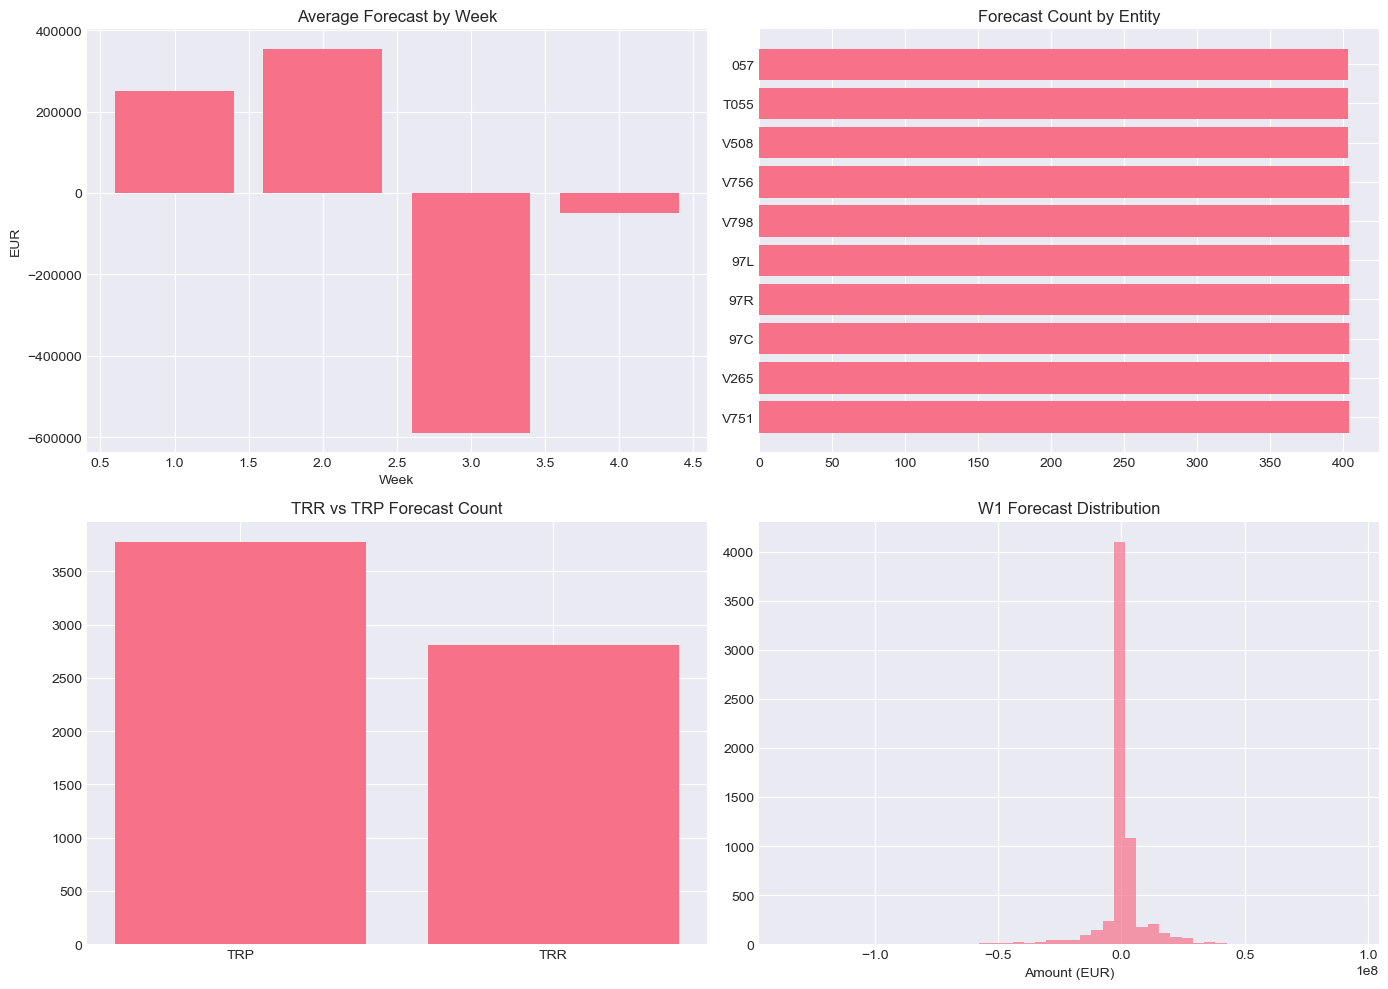

In [56]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Forecast by week
forecast_means = [lp_wide[f'W{i}_Forecast'].mean() for i in range(1, 5)]
axes[0,0].bar(range(1,5), forecast_means)
axes[0,0].set_title('Average Forecast by Week')
axes[0,0].set_xlabel('Week')
axes[0,0].set_ylabel('EUR')

# By entity
entity_counts = lp_wide['Entity'].value_counts().head(10)
axes[0,1].barh(range(len(entity_counts)), entity_counts.values)
axes[0,1].set_yticks(range(len(entity_counts)))
axes[0,1].set_yticklabels(entity_counts.index)
axes[0,1].set_title('Forecast Count by Entity')

# TRR vs TRP
liq_counts = lp_wide['Liquidity_Group'].value_counts()
axes[1,0].bar(liq_counts.index, liq_counts.values)
axes[1,0].set_title('TRR vs TRP Forecast Count')

# Distribution
axes[1,1].hist(lp_wide['W1_Forecast'].dropna(), bins=50, alpha=0.7)
axes[1,1].set_title('W1 Forecast Distribution')
axes[1,1].set_xlabel('Amount (EUR)')

plt.tight_layout()
plt.savefig('lp_eda.png', dpi=300)
print("\n✓ Saved: lp_eda.png")

In [57]:
print("[6.9/10] Forward fill missing forecasts") 
lp_wide['W2_Forecast'] = lp_wide['W2_Forecast'].fillna(lp_wide['W1_Forecast'])
lp_wide['W3_Forecast'] = lp_wide['W3_Forecast'].fillna(lp_wide['W2_Forecast'])
lp_wide['W4_Forecast'] = lp_wide['W4_Forecast'].fillna(lp_wide['W3_Forecast'])

[6.9/10] Forward fill missing forecasts


In [58]:
print("\nForecast Statistics (EUR):")
for w in ['W1_Forecast', 'W2_Forecast', 'W3_Forecast', 'W4_Forecast']:
    print(f"\n{w}:")
    print(f"  Mean: €{lp_wide[w].mean():,.0f}")
    print(f"  Median: €{lp_wide[w].median():,.0f}")
    print(f"  Missing: {lp_wide[w].isnull().sum()}")




Forecast Statistics (EUR):

W1_Forecast:
  Mean: €250,878
  Median: €-26,559
  Missing: 0

W2_Forecast:
  Mean: €352,150
  Median: €-18,560
  Missing: 0

W3_Forecast:
  Mean: €-558,251
  Median: €-16,528
  Missing: 0

W4_Forecast:
  Mean: €-29,035
  Median: €-15,925
  Missing: 0


In [59]:
actuals_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 578972 entries, 0 to 625319
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Entity                      578972 non-null  object        
 1   Value Date                  578972 non-null  datetime64[ns]
 2   Amount Functional Currency  578972 non-null  float64       
 3   Liquidity Group             578972 non-null  object        
 4   Week                        578972 non-null  period[W-SUN] 
 5   Year                        578972 non-null  int32         
 6   Month                       578972 non-null  int32         
 7   Quarter                     578972 non-null  int32         
 8   DayOfWeek                   578972 non-null  object        
 9   MonthName                   578972 non-null  object        
 10  DayOfMonth                  578972 non-null  int32         
 11  IsMonthEnd                  578972 non-null 